# Customer Segmentation Using RFM Analysis and K-Means Clustering

## Online Retail Customer Segmentation

This project analyzes customer purchasing behavior using Recency, Frequency, and Monetary (RFM) analysis and applies unsupervised machine learning with K-Means clustering to identify distinct customer segments.

The objective is to transform transactional retail data into meaningful customer groups and derive actionable business insights for targeted marketing and customer retention.

In [62]:
### 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded=files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [4]:
data=pd.read_excel("Online Retail.xlsx")
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [63]:
### 3. Initial Data Exploration
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
data.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [9]:
data.sample()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
204700,554694,21059,PARTY INVITES DINOSAURS,1,2011-05-25 17:06:00,1.63,NaN,United Kingdom


In [10]:
data.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [11]:
data.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [12]:
print('Rows',data.shape[0])
print("Columns",data.shape[1])

Rows 541909
Columns 8


In [13]:
print("Duplicated data",data.duplicated().sum())

Duplicated data 5268


In [14]:
data.drop_duplicates(inplace=True)

In [64]:
### 4. Data Cleaning and Preprocessing
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135037
Country,0


In [16]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer()
data['Description']=SimpleImputer(strategy='most_frequent').fit_transform(data[['Description']]).flatten()

In [17]:
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135037
Country,0


In [18]:
data.select_dtypes(include='number').skew()

,0
Quantity,-0.263921
UnitPrice,185.600448
CustomerID,0.034215


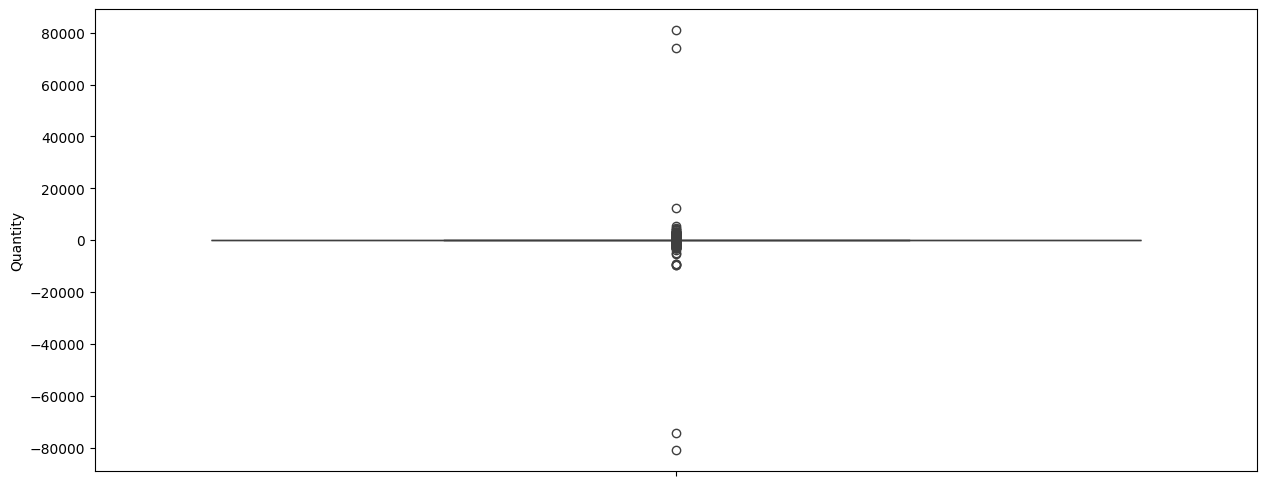

In [19]:
plt.figure(figsize=[15,6])
sns.boxplot(data['Quantity'])
plt.show()

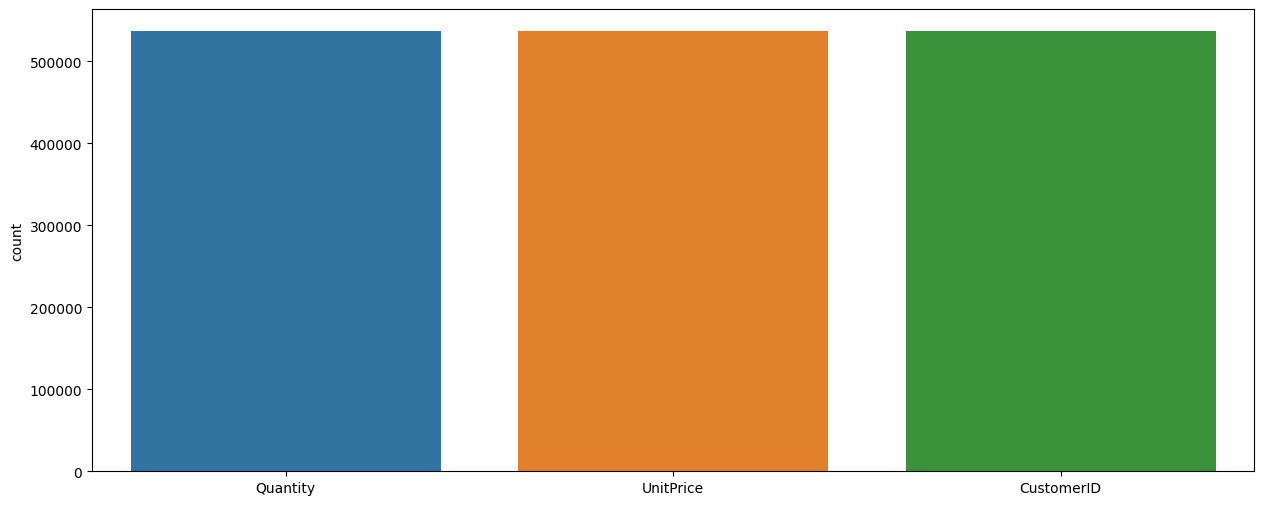

In [20]:
plt.figure(figsize=[15,6])
sns.countplot(data)
plt.show()

In [21]:
num1=data.select_dtypes(include='number')
num1

,Quantity,UnitPrice,CustomerID
0,6,2.55,17850.0
1,6,3.39,17850.0
2,8,2.75,17850.0
3,6,3.39,17850.0
4,6,3.39,17850.0
...,...,...,...
541904,12,0.85,12680.0
541905,6,2.10,12680.0
541906,4,4.15,12680.0
541907,4,4.15,12680.0


In [22]:
numerical_data=list(num1)

In [23]:
sample_data=data.sample(10000)

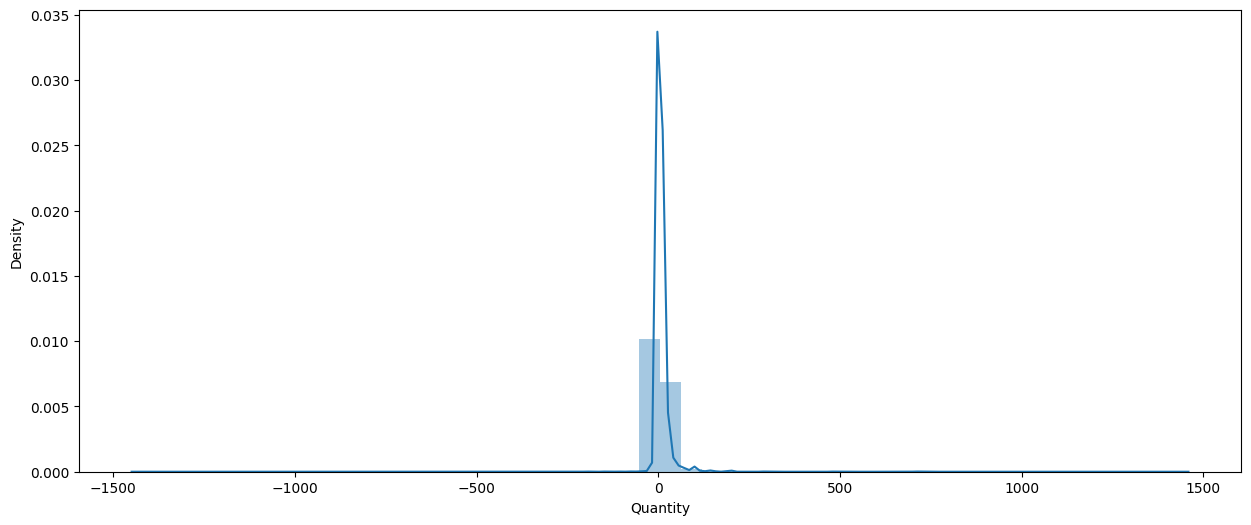

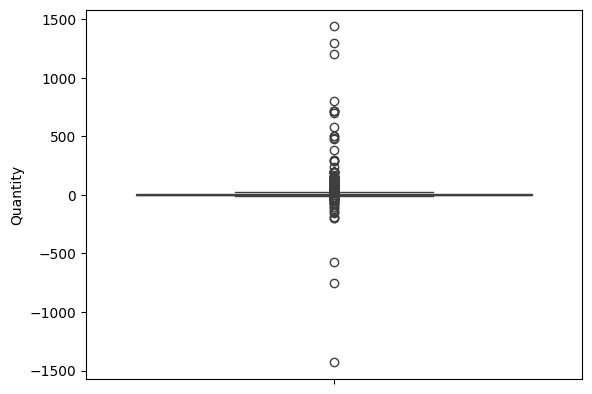

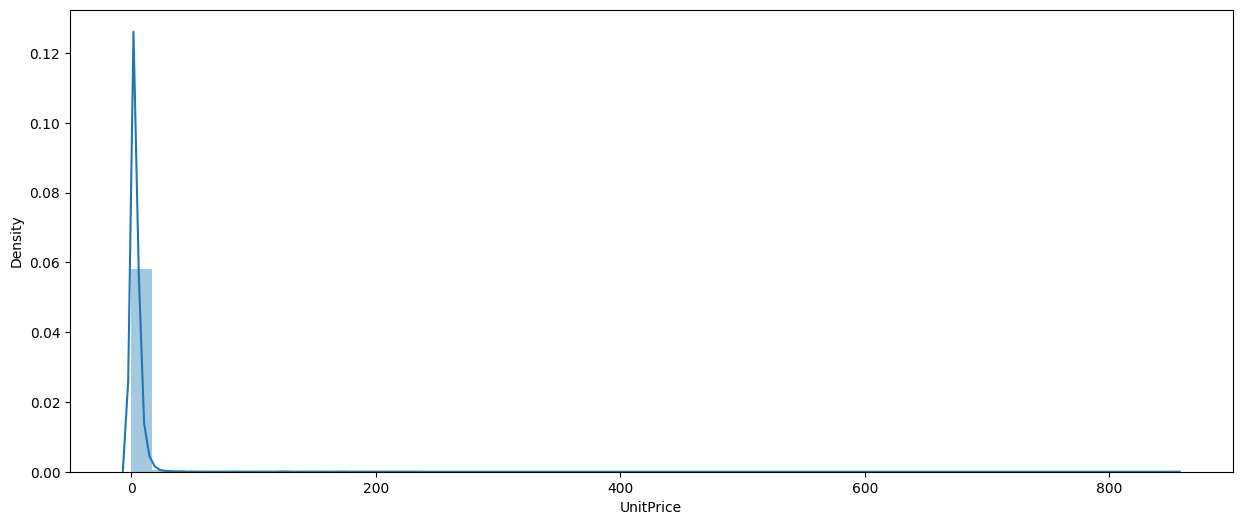

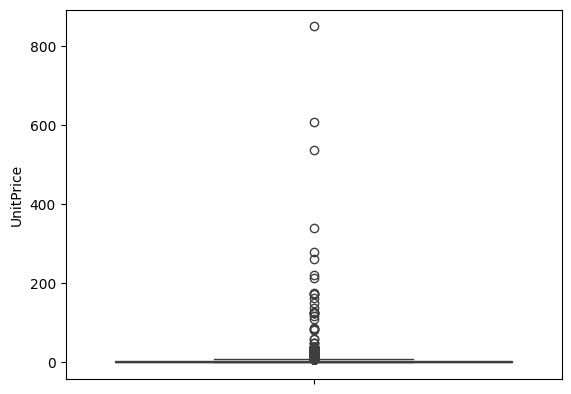

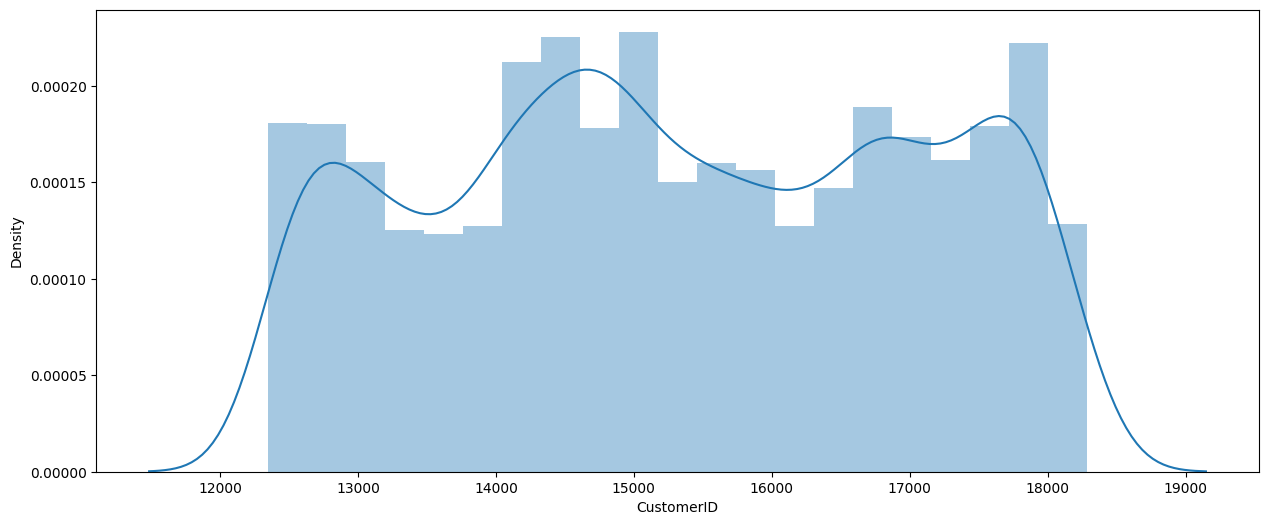

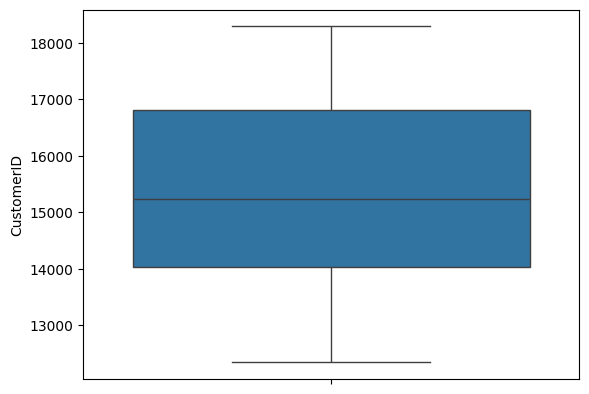

In [24]:
for columns in numerical_data:
  plt.figure(figsize=[15,6])
  sns.distplot(sample_data[columns])
  plt.show()
  sns.boxplot(sample_data[columns])
  plt.show()

In [25]:
def outlier_detection(data,column):
  Q1=data[column].quantile(0.25)
  Q3=data[column].quantile(0.75)
  IQR=Q3-Q1
  lower_limit=Q1-1.5*IQR
  upper_limit=Q3+1.5*IQR

  return data[(data[column]>lower_limit)&(data[column]<upper_limit)]

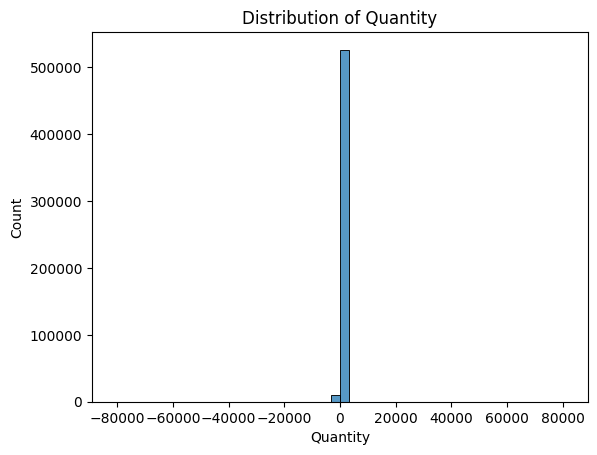

In [26]:
sns.histplot(data['Quantity'], bins=50)
plt.title("Distribution of Quantity")
plt.show()

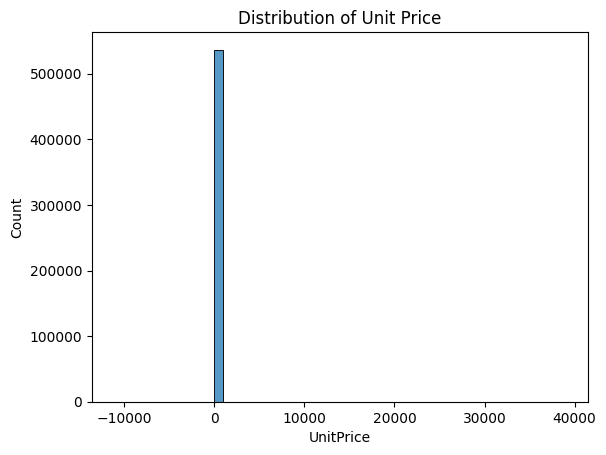

In [27]:
sns.histplot(data['UnitPrice'], bins=50)
plt.title("Distribution of Unit Price")
plt.show()

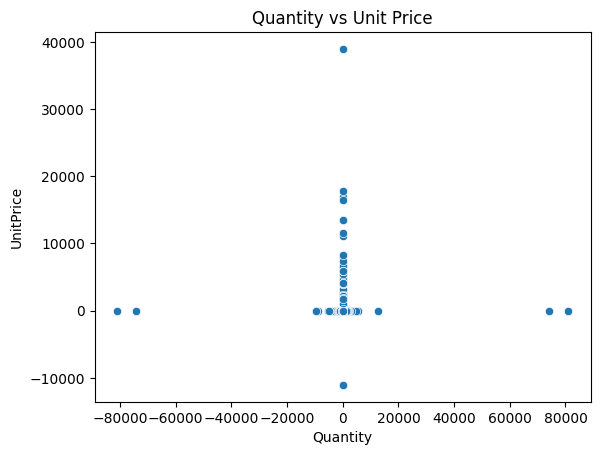

In [28]:
sns.scatterplot(data=data, x='Quantity', y='UnitPrice')
plt.title("Quantity vs Unit Price")
plt.show()

In [65]:
## 5. RFM Analysis
import pandas as pd

rfm_data = data[
    data['CustomerID'].notna() &
    (data['Quantity'] > 0)
].copy()

# Calculate total amount for each transaction
rfm_data['TotalAmount'] = rfm_data['Quantity'] * rfm_data['UnitPrice']

# Convert InvoiceDate to datetime
rfm_data['InvoiceDate'] = pd.to_datetime(rfm_data['InvoiceDate'])

# Set reference date as one day after the last transaction
reference_date = rfm_data['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = rfm_data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [30]:
rfm[rfm['Monetary'] < 0].shape

(0, 4)

In [31]:
rfm[rfm['Monetary'] < 0]

,CustomerID,Recency,Frequency,Monetary


In [32]:
rfm_data[rfm_data['TotalAmount'] < 0][
    ['CustomerID', 'InvoiceNo', 'Quantity', 'UnitPrice', 'TotalAmount']
].head(20)

,CustomerID,InvoiceNo,Quantity,UnitPrice,TotalAmount


In [33]:
rfm_data[rfm_data['Quantity'] < 0].shape

(0, 9)

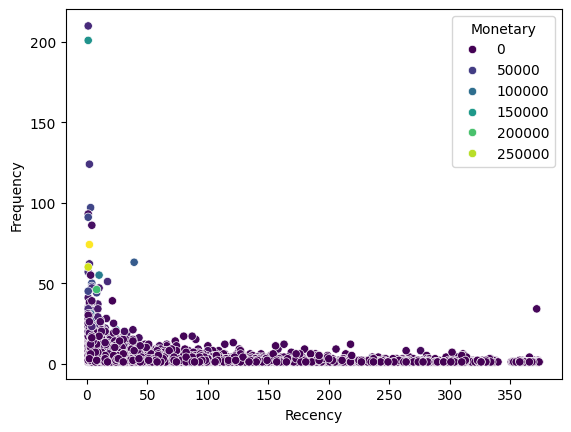

In [66]:
### 6. RFM Visualization
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Monetary',
    palette='viridis'
)
plt.show()

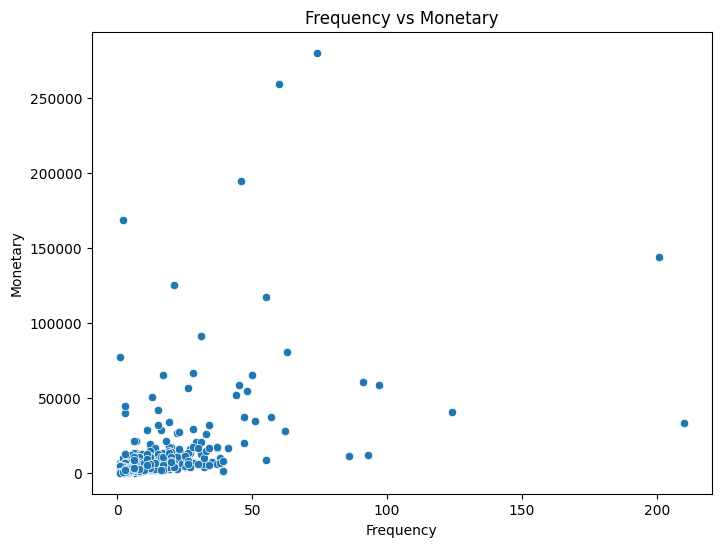

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary'
)

plt.title('Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.show()

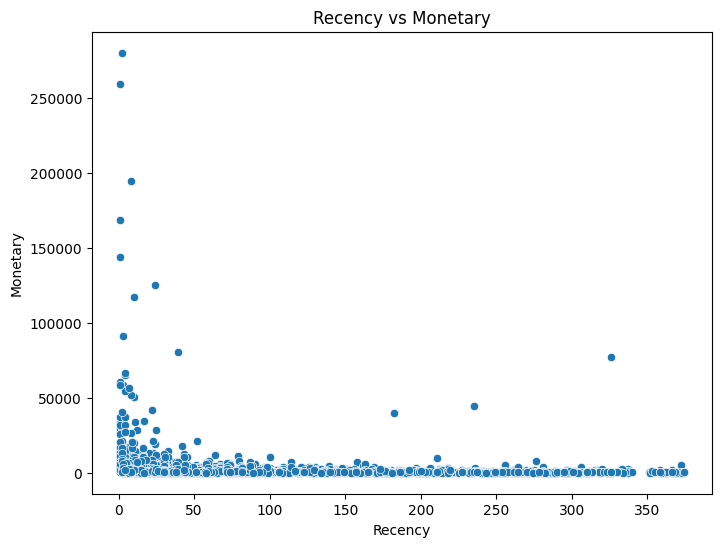

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary'
)

plt.title('Recency vs Monetary')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.show()

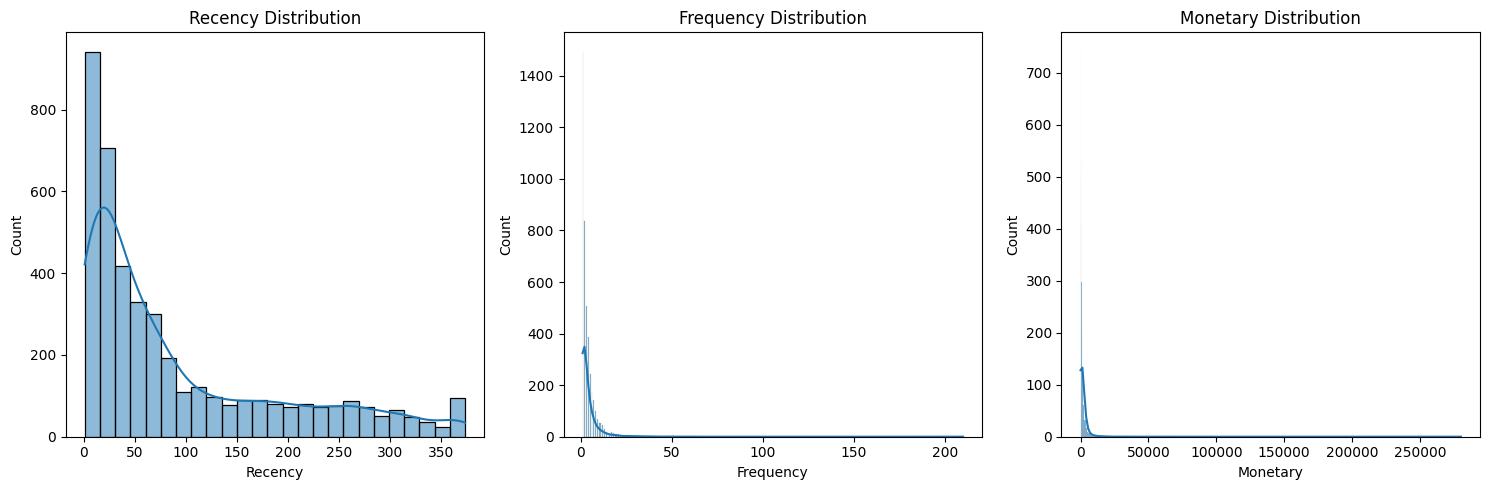

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(rfm['Recency'], kde=True, ax=axes[0])
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], kde=True, ax=axes[1])
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], kde=True, ax=axes[2])
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

In [38]:
import numpy as np

rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()

rfm_log = np.log1p(rfm_log)

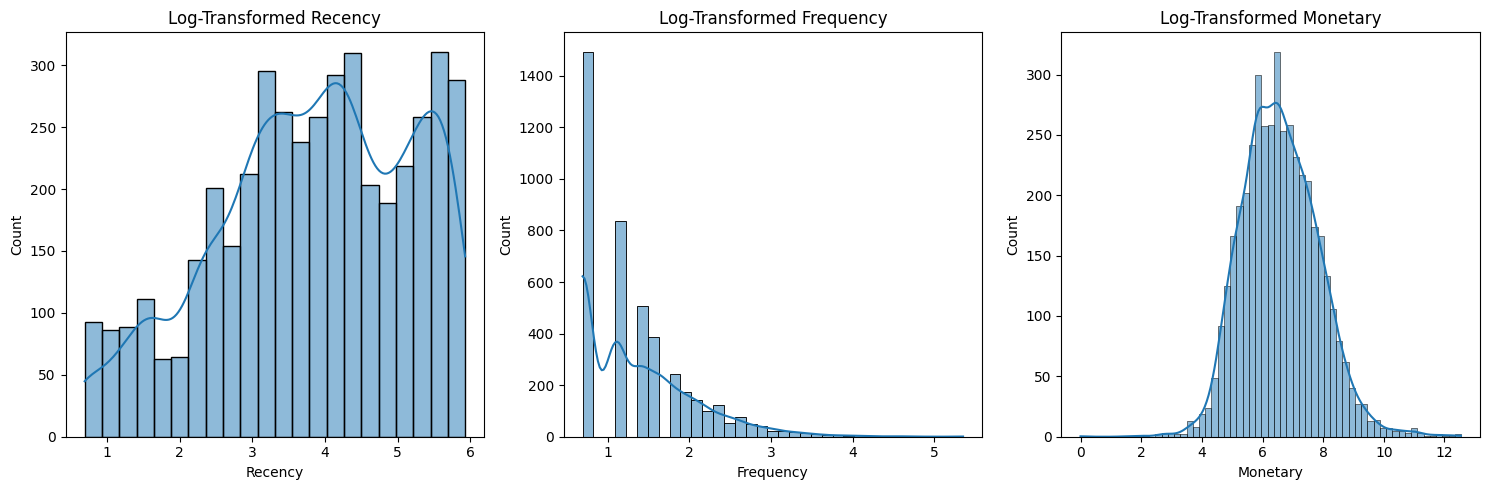

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(rfm_log['Recency'], kde=True, ax=axes[0])
axes[0].set_title('Log-Transformed Recency')

sns.histplot(rfm_log['Frequency'], kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Frequency')

sns.histplot(rfm_log['Monetary'], kde=True, ax=axes[2])
axes[2].set_title('Log-Transformed Monetary')

plt.tight_layout()
plt.show()

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(rfm_log)

In [44]:
print(x_scaled.shape)

(4339, 3)


In [45]:
print(rfm.shape)
print(rfm_log.shape)
print(x_scaled.shape)

(4339, 4)
(4339, 3)
(4339, 3)


In [56]:
rfm_data = data[data['CustomerID'].notna()].copy()

In [57]:
rfm_data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [58]:
rfm_data = data[data['CustomerID'].notna()].copy()

In [59]:
rfm_data.shape

(401604, 8)

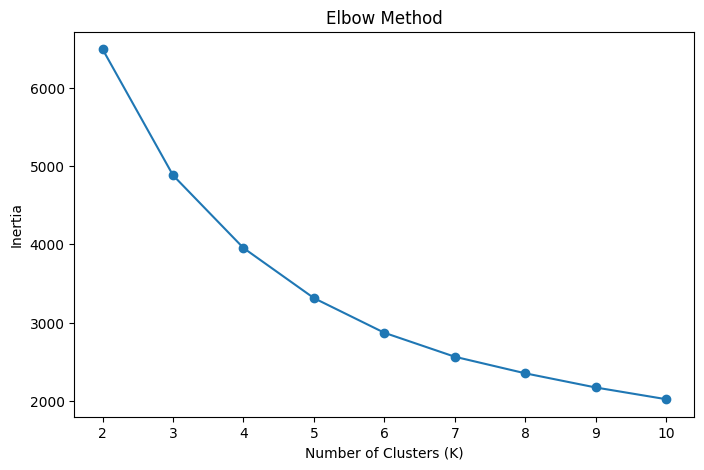

In [67]:
### 7. K-Means Clustering
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(x_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(range(2, 11))
plt.show()

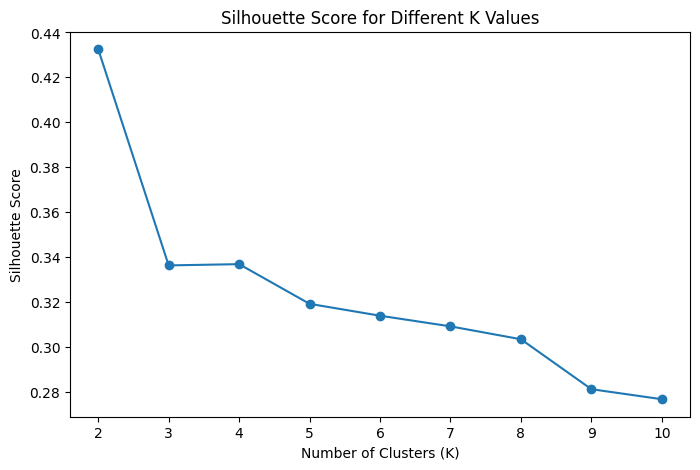

In [47]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(x_scaled)

    score = silhouette_score(x_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.xticks(range(2, 11))
plt.show()

In [48]:
from sklearn.cluster import KMeans

final_model = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = final_model.fit_predict(x_scaled)

In [49]:
print(rfm.shape)
print(rfm['Cluster'].value_counts().sort_index())

(4339, 5)
Cluster
0     843
1    1240
2     926
3     279
4    1051
Name: count, dtype: int64


In [50]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,4
1,12347.0,2,7,4310.00,2
2,12348.0,75,4,1797.24,4
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [51]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).round(2)

cluster_profile

,Recency,Frequency,Monetary,CustomerID
Cluster,,,,
0,25.21,1.71,407.10,843
1,205.62,1.21,281.26,1240
2,18.79,6.36,2450.69,926
3,10.49,22.91,15790.80,279
4,99.80,3.15,1446.52,1051


## Customer Segment Interpretation

Based on Recency, Frequency, and Monetary (RFM) characteristics, the five customer clusters can be interpreted as follows:

- **Cluster 0 – Recent Low-Value Customers:** Customers who purchased relatively recently but have low purchase frequency and moderate spending.

- **Cluster 1 – At-Risk / Dormant Customers:** Customers with very high recency, low purchase frequency, and the lowest monetary value, indicating low recent engagement.

- **Cluster 2 – Loyal Valuable Customers:** Customers with recent purchases, relatively high purchase frequency, and high monetary value.

- **Cluster 3 – Champions / VIP Customers:** Customers with the lowest recency, highest purchase frequency, and extremely high monetary value. This represents the most valuable customer segment.

- **Cluster 4 – Mid-Value Customers:** Customers with moderate recency, moderate purchase frequency, and moderate-to-high monetary value.

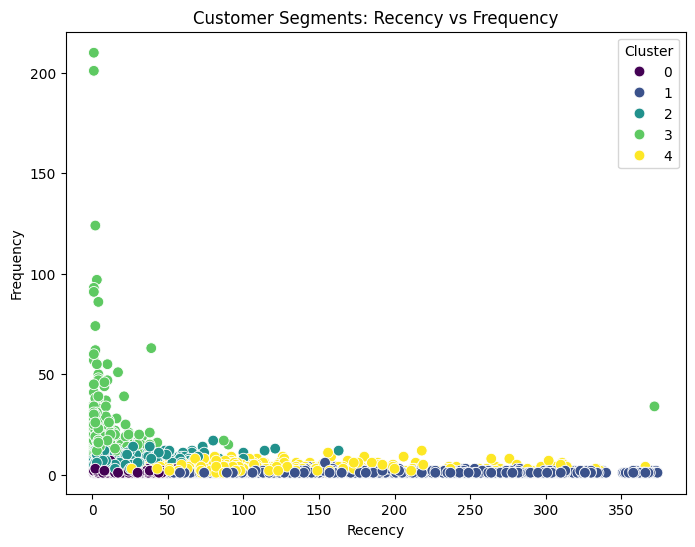

In [52]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    palette='viridis',
    s=60
)

plt.title('Customer Segments: Recency vs Frequency')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.legend(title='Cluster')
plt.show()

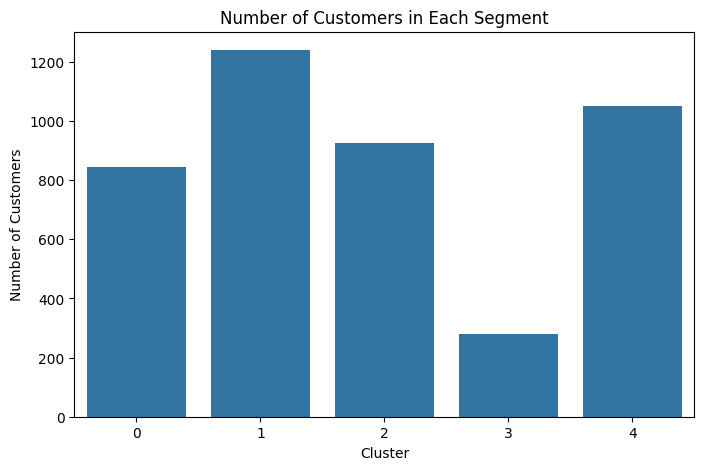

In [60]:
# Customer count in each cluster

cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title('Number of Customers in Each Segment')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.show()

### Customer Distribution Across Segments

The customer distribution shows that the five segments vary considerably in size. Cluster 1 contains the largest number of customers, while Cluster 3 contains the smallest number of customers. This indicates that the highly valuable Champion/VIP segment represents a relatively small but important portion of the customer base.

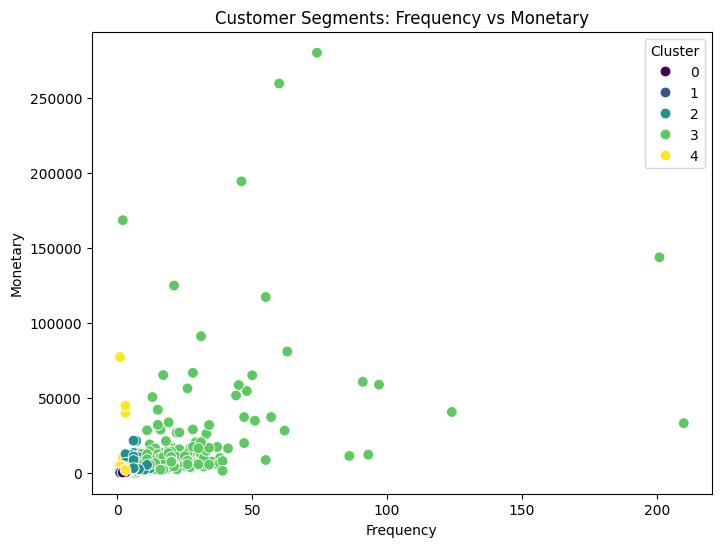

In [53]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=60
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')
plt.show()

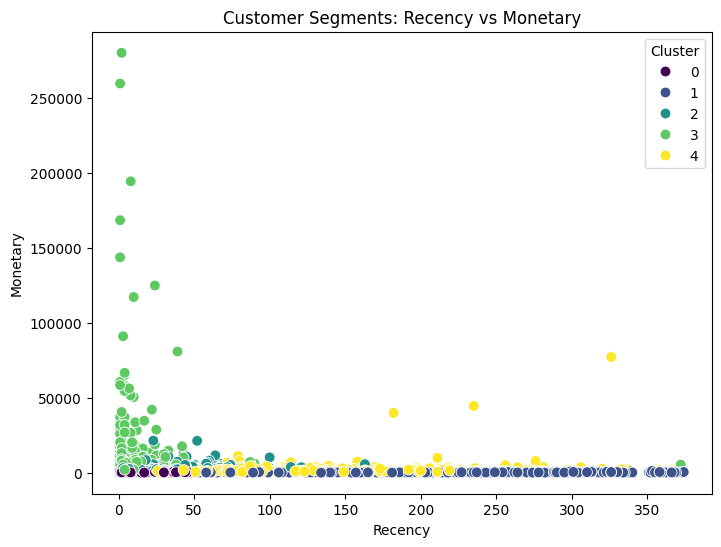

In [54]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=60
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')
plt.show()

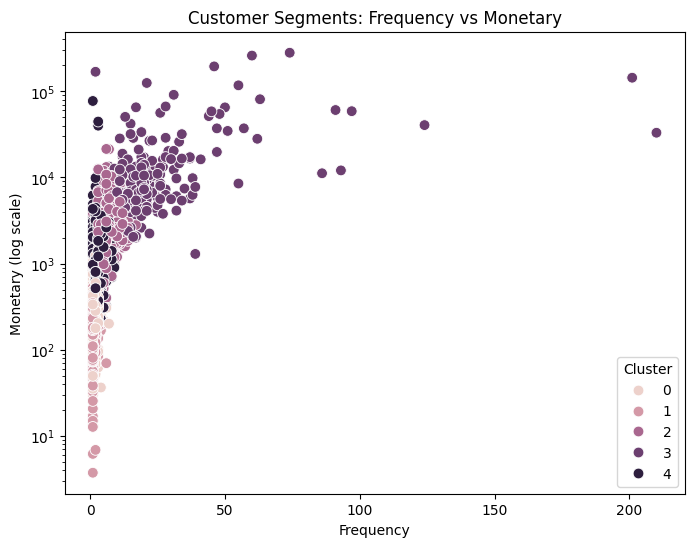

In [55]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    s=60
)

plt.yscale('log')
plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary (log scale)')
plt.legend(title='Cluster')
plt.show()

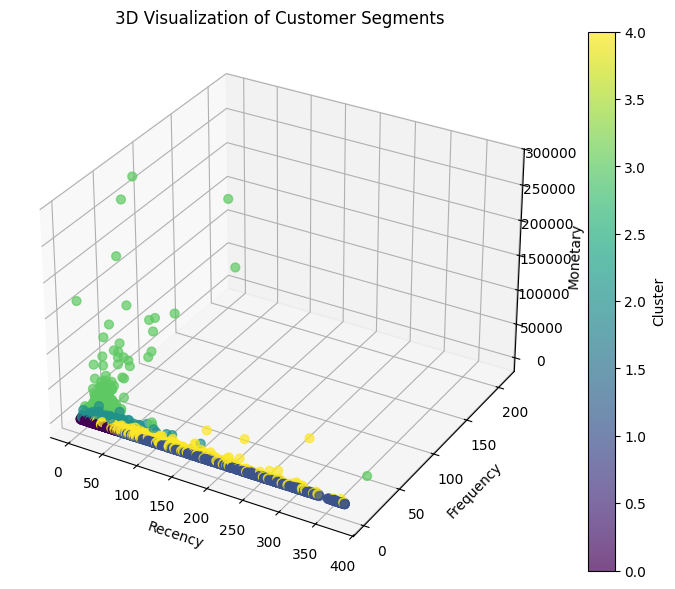

In [61]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis',
    s=40,
    alpha=0.7
)

ax.set_title('3D Visualization of Customer Segments')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

plt.colorbar(scatter, label='Cluster')
plt.show()

### 3D RFM Cluster Visualization

The three-dimensional visualization represents customers according to their Recency, Frequency, and Monetary values. The separation of observations across these dimensions illustrates the differences in purchasing behavior captured by the K-Means clustering model.

# Conclusion

This project successfully segmented customers of the Online Retail dataset using RFM (Recency, Frequency, and Monetary) analysis and K-Means clustering.

The analysis identified five distinct customer segments with different purchasing behaviors. The segments range from low-engagement and at-risk customers to highly valuable and frequent customers.

The cluster analysis demonstrates that customer behavior is not uniform across the entire customer base. By identifying differences in recency, purchase frequency, and monetary value, businesses can develop targeted marketing and retention strategies for each customer segment.

The identified customer segments can therefore be used to support personalized marketing, customer retention, loyalty programs, re-engagement campaigns, and targeted promotional strategies.

Overall, the project demonstrates how unsupervised machine learning combined with RFM analysis can transform transactional customer data into actionable customer segmentation insights.